# Lab 1: Value-Based Deep RL — SOLUTION

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

**This notebook contains the complete solution. Do not share with students.**

In [14]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

from replay_buffer import ReplayBuffer
from networks import DQNNetwork, DuelingDQNNetwork

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Resolve experiments directory relative to this notebook's location
_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f"Experiments directory: {EXPERIMENTS_DIR}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Using device: cuda
Setup complete!


## DQN Agent — Complete Solution

In [15]:
class DQNAgent:
    """DQN Agent with support for Double DQN and Dueling DQN."""

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 2.5e-4,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay: int = 50000,
        buffer_size: int = 10000,
        batch_size: int = 128,
        target_network_frequency: int = 500,
        max_grad_norm: float = 10.0,
        use_double_dqn: bool = False,
        use_dueling: bool = False,
        seed: int = 42,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_network_frequency = target_network_frequency
        self.max_grad_norm = max_grad_norm
        self.use_double_dqn = use_double_dqn
        self.steps_done = 0

        # SOLUTION: Initialize components
        self.replay_buffer = ReplayBuffer(capacity=buffer_size, seed=seed)

        NetworkClass = DuelingDQNNetwork if use_dueling else DQNNetwork
        self.q_network = NetworkClass(state_dim, action_dim).to(device)
        self.target_network = NetworkClass(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

    def get_epsilon(self):
        """Compute current epsilon using linear decay."""
        # SOLUTION: linear schedule matching CleanRL's exploration_fraction logic
        eps = self.epsilon_start - self.steps_done * (self.epsilon_start - self.epsilon_end) / self.epsilon_decay
        return max(self.epsilon_end, eps)

    def select_action(self, state):
        """Select an action using epsilon-greedy policy."""
        # SOLUTION
        self.steps_done += 1
        eps = self.get_epsilon()

        if random.random() < eps:
            return random.randrange(self.action_dim)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.q_network(state_tensor)
                return q_values.argmax(dim=1).item()

    def compute_loss(self, batch):
        """Compute the DQN loss (or Double DQN loss)."""
        states, actions, rewards, next_states, dones = batch

        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)

        # SOLUTION: Current Q-values for taken actions
        current_q = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # SOLUTION: Target Q-values (no gradient)
        with torch.no_grad():
            if self.use_double_dqn:
                # Double DQN: online network selects action, target network evaluates it
                best_actions = self.q_network(next_states).argmax(dim=1)
                next_q = self.target_network(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
            else:
                # Standard DQN: target network selects and evaluates
                next_q = self.target_network(next_states).max(dim=1)[0]

            target_q = rewards + self.gamma * next_q * (1 - dones)

        # SOLUTION: MSE loss — matches CleanRL reference implementation
        loss = F.mse_loss(current_q, target_q)
        return loss

    def train_step(self, global_step: int):
        """Perform one training step."""
        # SOLUTION
        if len(self.replay_buffer) < self.batch_size:
            return None

        batch = self.replay_buffer.sample(self.batch_size)
        loss = self.compute_loss(batch)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), self.max_grad_norm)
        self.optimizer.step()

        # Hard target network update — copy weights every target_network_frequency steps
        if global_step % self.target_network_frequency == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        return loss.item()

print("DQNAgent class defined (SOLUTION)")

DQNAgent class defined (SOLUTION)


## Training Loop — Complete Solution

In [16]:
def train_dqn(
    env_name: str = "CartPole-v1",
    num_episodes: int = 500,
    learning_starts: int = 1000,
    train_frequency: int = 10,
    use_double_dqn: bool = False,
    use_dueling: bool = False,
    seed: int = 42,
    solve_threshold: float = None,
    **agent_kwargs,
):
    """
    Train a DQN agent and return training metrics.

    Args:
        num_episodes:     Maximum number of episodes.
        learning_starts:  Steps of random play before training begins.
        train_frequency:  Train every N environment steps (CleanRL style).
        solve_threshold:  Stop early when avg reward (last 100 eps) >= this value.
        **agent_kwargs:   Passed directly to DQNAgent (e.g. buffer_size, lr).
    """
    set_seed(seed)

    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        use_double_dqn=use_double_dqn,
        use_dueling=use_dueling,
        seed=seed,
        **agent_kwargs,
    )

    episode_rewards = []
    episode_lengths = []
    losses = []
    epsilons = []
    global_step = 0

    for episode in range(num_episodes):
        obs, info = env.reset(seed=seed + episode)
        episode_reward = 0
        episode_loss = []

        for step in range(10000):
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(obs, action, reward, next_obs, float(done))
            global_step += 1

            # CleanRL style: only train after learning_starts, every train_frequency steps
            if global_step > learning_starts and global_step % train_frequency == 0:
                loss = agent.train_step(global_step)
                if loss is not None:
                    episode_loss.append(loss)

            obs = next_obs
            episode_reward += reward

            if done:
                break

        episode_rewards.append(episode_reward)
        episode_lengths.append(step + 1)
        losses.extend(episode_loss)
        epsilons.append(agent.get_epsilon())

        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            recent_losses = [l for l in losses[-500:] if l is not None]
            avg_loss = np.mean(recent_losses) if recent_losses else 0.0
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Avg Reward (50): {avg_reward:.1f} | "
                  f"Avg Loss: {avg_loss:.4f} | "
                  f"Epsilon: {agent.get_epsilon():.3f} | "
                  f"Buffer: {len(agent.replay_buffer)}")

        # Early stopping once environment is solved
        if solve_threshold is not None and len(episode_rewards) >= 100:
            if np.mean(episode_rewards[-100:]) >= solve_threshold:
                print(f"Solved at episode {episode+1}! "
                      f"Avg reward (last 100): {np.mean(episode_rewards[-100:]):.1f}")
                break

    env.close()

    return {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'losses': losses,
        'epsilons': epsilons,
        'agent': agent,
    }

print("Training function defined (SOLUTION)")

Training function defined (SOLUTION)


## Plotting Utilities

In [17]:
def _save_plot(fig, title):
    """Save figure to experiments/plots/ using the plot title as filename."""
    try:
        plots_dir = os.path.join(EXPERIMENTS_DIR, "plots")
        os.makedirs(plots_dir, exist_ok=True)
        filename = title.lower().replace(" ", "_").replace("/", "_").replace("—", "").replace(":", "").strip("_") + ".png"
        filepath = os.path.join(plots_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches="tight")
        print(f"Plot saved: {filepath}")
    except Exception as e:
        print(f"Could not save plot: {e}")


def plot_training_results(results, title="DQN Training", window=50):
    """Plot training curves: rewards, losses, and epsilon. Saves to experiments/plots/."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    rewards = results['episode_rewards']
    axes[0].plot(rewards, alpha=0.3, color='blue', label='Raw')
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(rewards)), moving_avg, color='blue', label=f'{window}-ep avg')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Reward')
    axes[0].set_title(f'{title} — Episode Rewards')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    valid_losses = [l for l in results['losses'] if l is not None]
    if valid_losses:
        axes[1].plot(valid_losses, alpha=0.5, color='red')
        axes[1].set_xlabel('Training Step')
        axes[1].set_ylabel('Loss')
        axes[1].set_title(f'{title} — Training Loss')
        axes[1].grid(True, alpha=0.3)

    axes[2].plot(results['epsilons'], color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Epsilon')
    axes[2].set_title(f'{title} — Exploration Rate')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()


def plot_comparison(all_results, title="Method Comparison", window=50):
    """Plot reward comparison across multiple methods/seeds. Saves to experiments/plots/."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple']

    for idx, (name, results_list) in enumerate(all_results.items()):
        color = colors[idx % len(colors)]
        min_len = min(len(r['episode_rewards']) for r in results_list)
        all_rewards = np.array([r['episode_rewards'][:min_len] for r in results_list])

        if min_len >= window:
            smoothed = np.array([
                np.convolve(row, np.ones(window)/window, mode='valid')
                for row in all_rewards
            ])
            mean = smoothed.mean(axis=0)
            std = smoothed.std(axis=0)
            x = range(window-1, min_len)
        else:
            mean = all_rewards.mean(axis=0)
            std = all_rewards.std(axis=0)
            x = range(min_len)

        ax.plot(x, mean, color=color, label=name)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()

print("Plotting utilities defined!")

Plotting utilities defined!


## Train DQN on CartPole-v1

Episode 50/2000 | Avg Reward (50): 20.8 | Avg Loss: 1.0839 | Epsilon: 0.980 | Buffer: 1039
Episode 100/2000 | Avg Reward (50): 20.1 | Avg Loss: 0.6195 | Epsilon: 0.961 | Buffer: 2045
Episode 150/2000 | Avg Reward (50): 21.1 | Avg Loss: 0.6801 | Epsilon: 0.941 | Buffer: 3099
Episode 200/2000 | Avg Reward (50): 20.0 | Avg Loss: 0.8599 | Epsilon: 0.922 | Buffer: 4099
Episode 250/2000 | Avg Reward (50): 19.4 | Avg Loss: 1.0474 | Epsilon: 0.904 | Buffer: 5069
Episode 300/2000 | Avg Reward (50): 19.0 | Avg Loss: 1.2073 | Epsilon: 0.886 | Buffer: 6021
Episode 350/2000 | Avg Reward (50): 22.7 | Avg Loss: 1.5079 | Epsilon: 0.864 | Buffer: 7155
Episode 400/2000 | Avg Reward (50): 34.5 | Avg Loss: 1.9492 | Epsilon: 0.831 | Buffer: 8881
Episode 450/2000 | Avg Reward (50): 28.1 | Avg Loss: 2.3296 | Epsilon: 0.805 | Buffer: 10000
Episode 500/2000 | Avg Reward (50): 27.7 | Avg Loss: 2.8380 | Epsilon: 0.778 | Buffer: 10000
Episode 550/2000 | Avg Reward (50): 37.0 | Avg Loss: 3.7904 | Epsilon: 0.743 | 

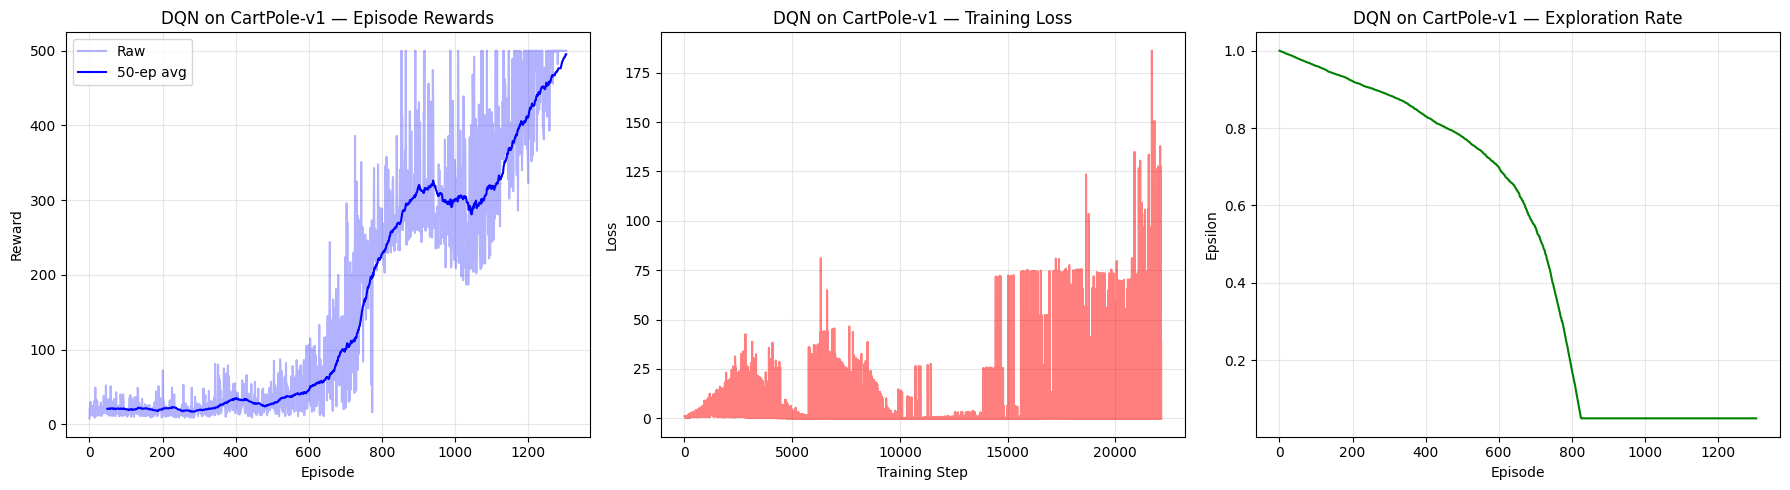


Average reward (last 100 episodes): 475.0
CartPole SOLVED!


In [18]:
set_seed(42)
results_dqn = train_dqn(
    env_name="CartPole-v1",
    num_episodes=2000,
    solve_threshold=475,
    use_double_dqn=False,
    use_dueling=False,
    seed=42,
)

plot_training_results(results_dqn, title="DQN on CartPole-v1")

last_100 = results_dqn['episode_rewards'][-100:]
avg_reward = np.mean(last_100)
print(f"\nAverage reward (last 100 episodes): {avg_reward:.1f}")
if avg_reward >= 475:
    print("CartPole SOLVED!")
else:
    print(f"Not yet solved (needs >= 475). Keep training or tune hyperparameters.")

## Visualize the Learned Policy

Record a video of the trained agent and analyze its Q-values.

In [19]:
def record_agent_video(agent, env_name="CartPole-v1", video_dir=None, num_episodes=3, seed=0):
    """Record the trained agent playing with greedy policy. Saves to experiments/videos/."""
    if video_dir is None:
        video_dir = os.path.join(EXPERIMENTS_DIR, 'videos')
    os.makedirs(video_dir, exist_ok=True)

    env = gym.make(env_name, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(
        env,
        video_folder=video_dir,
        episode_trigger=lambda ep: True,
        name_prefix=f"dqn_{env_name}"
    )

    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        episode_reward = 0
        for step in range(10000):
            with torch.no_grad():
                state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
                action = agent.q_network(state_tensor).argmax(dim=1).item()
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            if terminated or truncated:
                break
        print(f"Episode {ep+1}: reward = {episode_reward:.0f}, length = {step+1}")

    env.close()
    video_files = sorted([f for f in os.listdir(video_dir) if f.endswith('.mp4')])
    if video_files:
        video_path = os.path.join(video_dir, video_files[-1])
        print(f"\nVideo saved to: {video_path}")
        return video_path
    return None


def evaluate_and_plot(agent, env_name="CartPole-v1", num_episodes=20, seed=0):
    """Evaluate the trained agent and plot Q-value analysis."""
    env = gym.make(env_name)
    rewards, all_q_values = [], []

    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        episode_reward = 0
        for step in range(10000):
            with torch.no_grad():
                state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
                q_values = agent.q_network(state_tensor)
                all_q_values.append(q_values.cpu().numpy().flatten())
                action = q_values.argmax(dim=1).item()
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            if terminated or truncated:
                break
        rewards.append(episode_reward)

    env.close()
    q_values = np.array(all_q_values)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].bar(range(len(rewards)), rewards, color='steelblue', alpha=0.8)
    axes[0].axhline(y=np.mean(rewards), color='red', linestyle='--', label=f'Mean: {np.mean(rewards):.1f}')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')
    axes[0].set_title(f'Evaluation — {num_episodes} episodes'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    for a in range(q_values.shape[1]):
        axes[1].hist(q_values[:, a], bins=50, alpha=0.6, label=f'Action {a}')
    axes[1].set_xlabel('Q-value'); axes[1].set_ylabel('Count')
    axes[1].set_title('Q-value Distribution by Action'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    q_diff = q_values[:, 1] - q_values[:, 0]
    axes[2].hist(q_diff, bins=50, color='purple', alpha=0.7)
    axes[2].axvline(x=0, color='red', linestyle='--', label='No preference')
    axes[2].set_xlabel('Q(right) - Q(left)'); axes[2].set_ylabel('Count')
    axes[2].set_title('Action Preference'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"Evaluation: {np.mean(rewards):.1f} ± {np.std(rewards):.1f} "
          f"(min={min(rewards):.0f}, max={max(rewards):.0f})")

print("Visualization functions defined!")

Experiments directory: /home/amath/Desktop/course/tdde78labsolution/labs/lab1_value_based/experiments
Visualization functions defined!


In [20]:
video_path = record_agent_video(results_dqn['agent'], env_name="CartPole-v1", num_episodes=3)
if video_path:
    display(Video(video_path, embed=True, width=480))

Episode 1: reward = 500, length = 500
Episode 2: reward = 500, length = 500
Episode 3: reward = 500, length = 500

Video saved to: /home/amath/Desktop/course/tdde78labsolution/labs/lab1_value_based/experiments/videos/dqn_CartPole-v1-episode-2.mp4


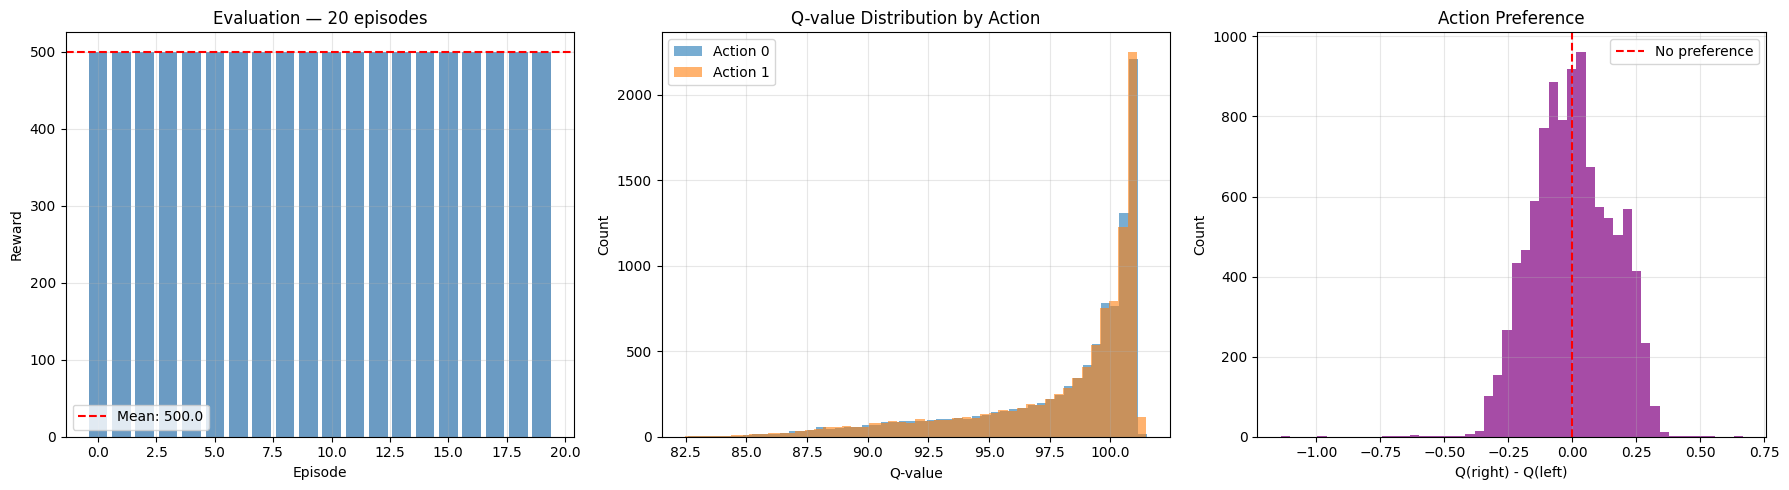

Evaluation: 500.0 ± 0.0 (min=500, max=500)


In [21]:
evaluate_and_plot(results_dqn['agent'], env_name="CartPole-v1", num_episodes=20)

## B.1 — DQN vs Double DQN vs Dueling DQN

Episode 50/2000 | Avg Reward (50): 20.8 | Avg Loss: 1.0839 | Epsilon: 0.980 | Buffer: 1039
Episode 100/2000 | Avg Reward (50): 20.1 | Avg Loss: 0.6195 | Epsilon: 0.961 | Buffer: 2045
Episode 150/2000 | Avg Reward (50): 21.1 | Avg Loss: 0.6801 | Epsilon: 0.941 | Buffer: 3099
Episode 200/2000 | Avg Reward (50): 20.0 | Avg Loss: 0.8599 | Epsilon: 0.922 | Buffer: 4099
Episode 250/2000 | Avg Reward (50): 19.4 | Avg Loss: 1.0474 | Epsilon: 0.904 | Buffer: 5069
Episode 300/2000 | Avg Reward (50): 19.0 | Avg Loss: 1.2073 | Epsilon: 0.886 | Buffer: 6021
Episode 350/2000 | Avg Reward (50): 22.7 | Avg Loss: 1.5079 | Epsilon: 0.864 | Buffer: 7155
Episode 400/2000 | Avg Reward (50): 34.5 | Avg Loss: 1.9492 | Epsilon: 0.831 | Buffer: 8881
Episode 450/2000 | Avg Reward (50): 28.1 | Avg Loss: 2.3296 | Epsilon: 0.805 | Buffer: 10000
Episode 500/2000 | Avg Reward (50): 27.7 | Avg Loss: 2.8380 | Epsilon: 0.778 | Buffer: 10000
Episode 550/2000 | Avg Reward (50): 37.0 | Avg Loss: 3.7904 | Epsilon: 0.743 | 

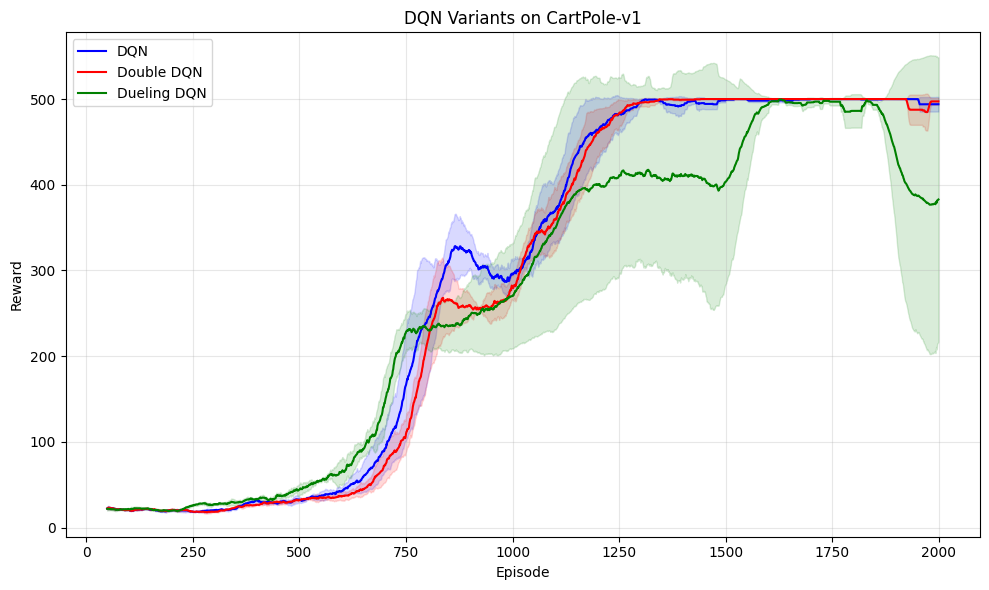

DQN: 496.9 ± 4.2
Double DQN: 492.4 ± 10.8
Dueling DQN: 384.8 ± 162.9


In [22]:
seeds = [42, 123, 456]

all_results = {
    'DQN':        [train_dqn(env_name="CartPole-v1", num_episodes=2000, seed=s) for s in seeds],
    'Double DQN': [train_dqn(env_name="CartPole-v1", num_episodes=2000, use_double_dqn=True, seed=s) for s in seeds],
    'Dueling DQN':[train_dqn(env_name="CartPole-v1", num_episodes=2000, use_dueling=True, seed=s) for s in seeds],
}

plot_comparison(all_results, title="DQN Variants on CartPole-v1")

for name, results_list in all_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

## B.2 — DQN on LunarLander-v3

Episode 50/1000 | Avg Reward (50): -166.6 | Avg Loss: 92.7659 | Epsilon: 0.974 | Buffer: 5504
Episode 100/1000 | Avg Reward (50): -188.5 | Avg Loss: 90.6006 | Epsilon: 0.952 | Buffer: 10000
Episode 150/1000 | Avg Reward (50): -184.6 | Avg Loss: 57.1539 | Epsilon: 0.925 | Buffer: 10000
Episode 200/1000 | Avg Reward (50): -144.6 | Avg Loss: 50.6100 | Epsilon: 0.901 | Buffer: 10000
Episode 250/1000 | Avg Reward (50): -139.7 | Avg Loss: 49.0175 | Epsilon: 0.877 | Buffer: 10000
Episode 300/1000 | Avg Reward (50): -119.2 | Avg Loss: 54.3829 | Epsilon: 0.853 | Buffer: 10000
Episode 350/1000 | Avg Reward (50): -108.7 | Avg Loss: 40.7995 | Epsilon: 0.829 | Buffer: 10000
Episode 400/1000 | Avg Reward (50): -113.9 | Avg Loss: 53.2401 | Epsilon: 0.804 | Buffer: 10000
Episode 450/1000 | Avg Reward (50): -99.0 | Avg Loss: 57.1321 | Epsilon: 0.779 | Buffer: 10000
Episode 500/1000 | Avg Reward (50): -78.7 | Avg Loss: 54.7908 | Epsilon: 0.753 | Buffer: 10000
Episode 550/1000 | Avg Reward (50): -80.2 | 

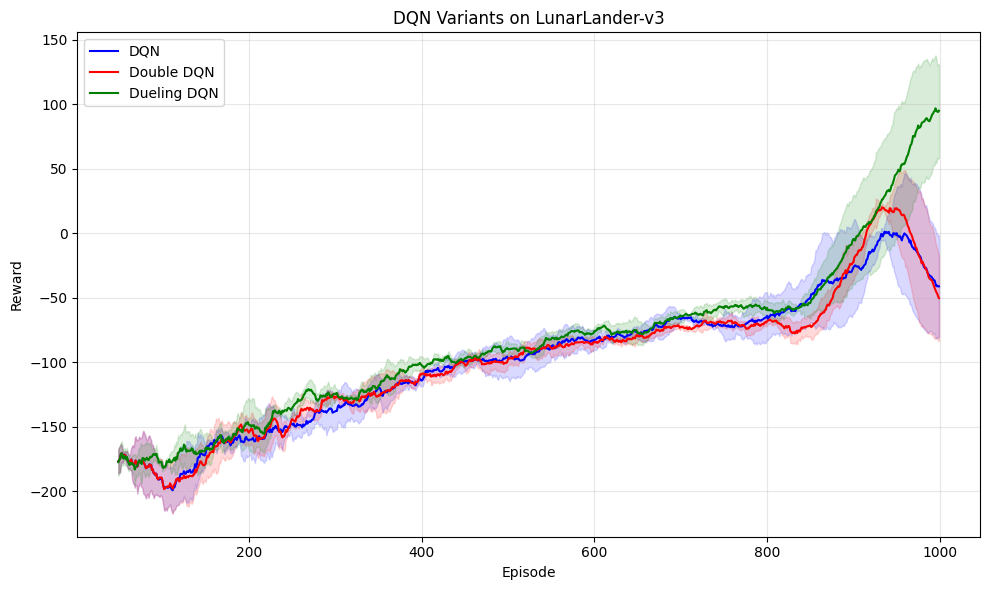

DQN: -21.2 ± 35.6
Double DQN: -15.6 ± 26.5
Dueling DQN: 70.2 ± 43.1
Episode 1: reward = 249, length = 250
Episode 2: reward = 84, length = 885
Episode 3: reward = 43, length = 1000

Video saved to: /home/amath/Desktop/course/tdde78labsolution/labs/lab1_value_based/experiments/videos/lunarlander/dqn_LunarLander-v3-episode-2.mp4


In [23]:
# LunarLander episodes are ~200-1000 steps, so epsilon_decay needs to be larger
seeds = [42, 123, 456]

lunar_results = {
    'DQN':        [train_dqn(env_name="LunarLander-v3", num_episodes=1000, epsilon_decay=200000, seed=s) for s in seeds],
    'Double DQN': [train_dqn(env_name="LunarLander-v3", num_episodes=1000, epsilon_decay=200000, use_double_dqn=True, seed=s) for s in seeds],
    'Dueling DQN':[train_dqn(env_name="LunarLander-v3", num_episodes=1000, epsilon_decay=200000, use_dueling=True, seed=s) for s in seeds],
}

plot_comparison(lunar_results, title="DQN Variants on LunarLander-v3")

for name, results_list in lunar_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

# Record video of the best agent (Dueling DQN, seed 42)
best_agent = lunar_results['Dueling DQN'][0]['agent']
lunar_video_path = record_agent_video(best_agent, env_name="LunarLander-v3", num_episodes=3,
                                      video_dir=os.path.join(EXPERIMENTS_DIR, "videos", "lunarlander"))
if lunar_video_path:
    display(Video(lunar_video_path, embed=True, width=600))

## B.3 — Ablation: Replay Buffer Size

Episode 50/2000 | Avg Reward (50): 21.0 | Avg Loss: 1.0608 | Epsilon: 0.980 | Buffer: 1000
Episode 100/2000 | Avg Reward (50): 23.4 | Avg Loss: 0.6284 | Epsilon: 0.958 | Buffer: 1000
Episode 150/2000 | Avg Reward (50): 24.7 | Avg Loss: 0.6927 | Epsilon: 0.934 | Buffer: 1000
Episode 200/2000 | Avg Reward (50): 18.4 | Avg Loss: 0.8997 | Epsilon: 0.917 | Buffer: 1000
Episode 250/2000 | Avg Reward (50): 17.9 | Avg Loss: 1.1100 | Epsilon: 0.900 | Buffer: 1000
Episode 300/2000 | Avg Reward (50): 20.2 | Avg Loss: 1.3281 | Epsilon: 0.881 | Buffer: 1000
Episode 350/2000 | Avg Reward (50): 23.5 | Avg Loss: 1.7030 | Epsilon: 0.858 | Buffer: 1000
Episode 400/2000 | Avg Reward (50): 27.3 | Avg Loss: 2.1217 | Epsilon: 0.832 | Buffer: 1000
Episode 450/2000 | Avg Reward (50): 26.0 | Avg Loss: 2.5293 | Epsilon: 0.808 | Buffer: 1000
Episode 500/2000 | Avg Reward (50): 35.1 | Avg Loss: 2.9320 | Epsilon: 0.774 | Buffer: 1000
Episode 550/2000 | Avg Reward (50): 29.5 | Avg Loss: 3.9455 | Epsilon: 0.746 | Bu

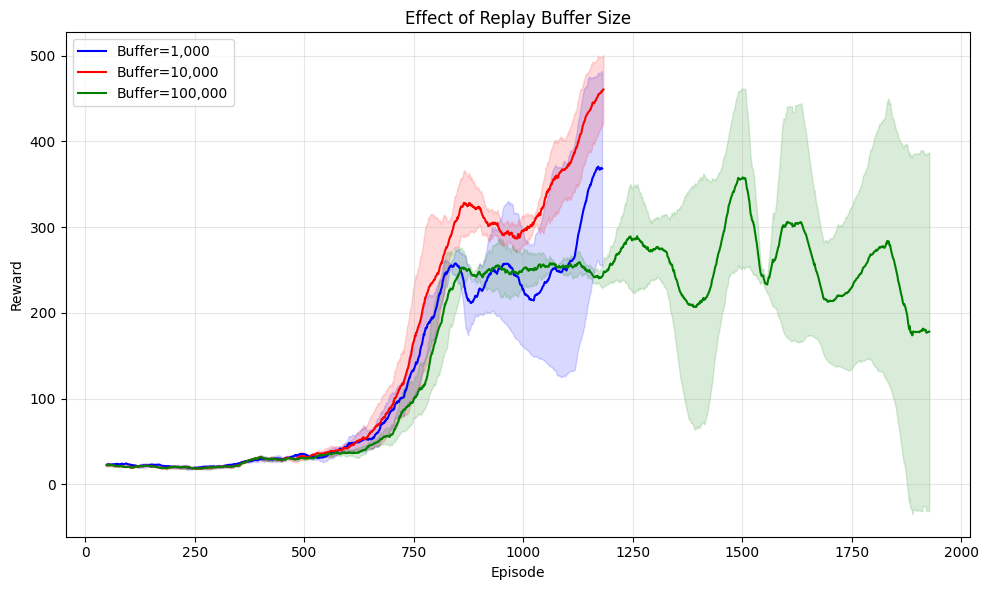

Buffer=1,000: 476.4 ± 0.5
Buffer=10,000: 475.1 ± 0.0
Buffer=100,000: 265.7 ± 189.9


In [24]:
seeds = [42, 123, 456]
buffer_sizes = [1000, 10000, 100000]

buffer_results = {}
for bs in buffer_sizes:
    buffer_results[f'Buffer={bs:,}'] = [
        train_dqn(env_name="CartPole-v1", num_episodes=2000, solve_threshold=475, buffer_size=bs, seed=s)
        for s in seeds
    ]

plot_comparison(buffer_results, title="Effect of Replay Buffer Size")

for name, results_list in buffer_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

## B.4 — Ablation: Target Network Update Frequency

Episode 50/2000 | Avg Reward (50): 20.8 | Avg Loss: 1.1066 | Epsilon: 0.980 | Buffer: 1039
Episode 100/2000 | Avg Reward (50): 20.1 | Avg Loss: 1.2524 | Epsilon: 0.961 | Buffer: 2045
Episode 150/2000 | Avg Reward (50): 19.0 | Avg Loss: 2.3072 | Epsilon: 0.943 | Buffer: 2994
Episode 200/2000 | Avg Reward (50): 22.3 | Avg Loss: 4.9478 | Epsilon: 0.922 | Buffer: 4111
Episode 250/2000 | Avg Reward (50): 24.3 | Avg Loss: 7.8783 | Epsilon: 0.899 | Buffer: 5324
Episode 300/2000 | Avg Reward (50): 18.1 | Avg Loss: 9.3761 | Epsilon: 0.882 | Buffer: 6229
Episode 350/2000 | Avg Reward (50): 19.4 | Avg Loss: 11.8341 | Epsilon: 0.863 | Buffer: 7199
Episode 400/2000 | Avg Reward (50): 22.8 | Avg Loss: 13.6760 | Epsilon: 0.842 | Buffer: 8339
Episode 450/2000 | Avg Reward (50): 27.9 | Avg Loss: 14.0078 | Epsilon: 0.815 | Buffer: 9734
Episode 500/2000 | Avg Reward (50): 27.5 | Avg Loss: 15.7652 | Epsilon: 0.789 | Buffer: 10000
Episode 550/2000 | Avg Reward (50): 28.1 | Avg Loss: 21.1568 | Epsilon: 0.76

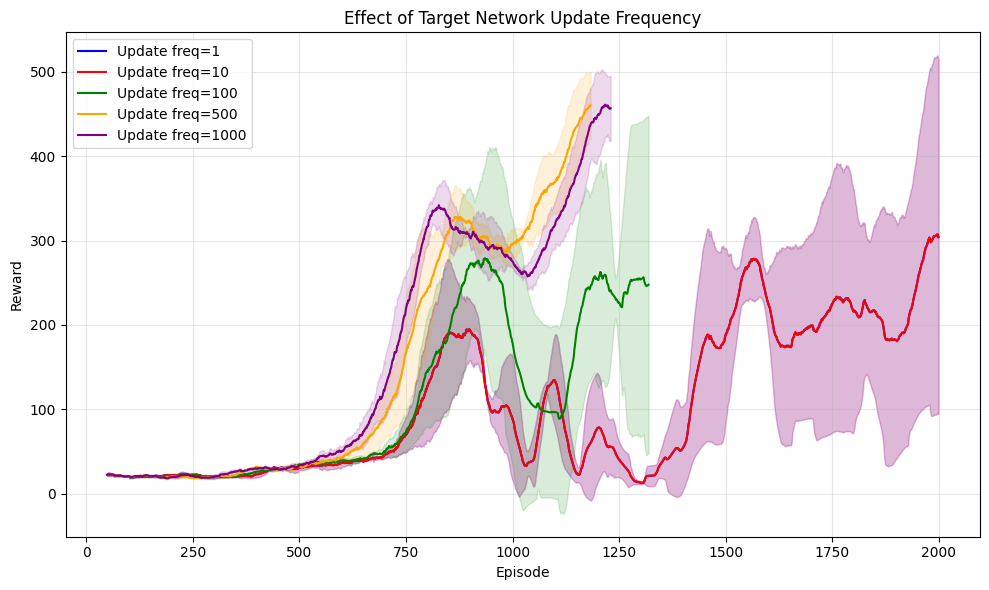

Update freq=1: 276.9 ± 182.8
Update freq=10: 276.9 ± 182.8
Update freq=100: 475.5 ± 0.3
Update freq=500: 475.1 ± 0.0
Update freq=1000: 475.8 ± 0.7


In [25]:
seeds = [42, 123, 456]
target_freqs = [1, 10, 100, 500, 1000]

target_results = {}
for freq in target_freqs:
    target_results[f'Update freq={freq}'] = [
        train_dqn(env_name="CartPole-v1", num_episodes=2000, solve_threshold=475, target_network_frequency=freq, seed=s)
        for s in seeds
    ]

plot_comparison(target_results, title="Effect of Target Network Update Frequency")

for name, results_list in target_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

## B.5 — Ablation: Epsilon Decay Schedule

Episode 50/2000 | Avg Reward (50): 18.8 | Avg Loss: 0.0000 | Epsilon: 0.821 | Buffer: 941
Episode 100/2000 | Avg Reward (50): 18.4 | Avg Loss: 0.6779 | Epsilon: 0.646 | Buffer: 1861
Episode 150/2000 | Avg Reward (50): 14.9 | Avg Loss: 0.6784 | Epsilon: 0.505 | Buffer: 2605
Episode 200/2000 | Avg Reward (50): 12.8 | Avg Loss: 0.7833 | Epsilon: 0.384 | Buffer: 3243
Episode 250/2000 | Avg Reward (50): 11.3 | Avg Loss: 0.8692 | Epsilon: 0.276 | Buffer: 3810
Episode 300/2000 | Avg Reward (50): 10.9 | Avg Loss: 0.9212 | Epsilon: 0.173 | Buffer: 4355
Episode 350/2000 | Avg Reward (50): 10.2 | Avg Loss: 0.9654 | Epsilon: 0.076 | Buffer: 4865
Episode 400/2000 | Avg Reward (50): 11.4 | Avg Loss: 1.0512 | Epsilon: 0.050 | Buffer: 5437
Episode 450/2000 | Avg Reward (50): 10.5 | Avg Loss: 1.1479 | Epsilon: 0.050 | Buffer: 5961
Episode 500/2000 | Avg Reward (50): 27.3 | Avg Loss: 1.4737 | Epsilon: 0.050 | Buffer: 7326
Episode 550/2000 | Avg Reward (50): 45.9 | Avg Loss: 2.1689 | Epsilon: 0.050 | Buf

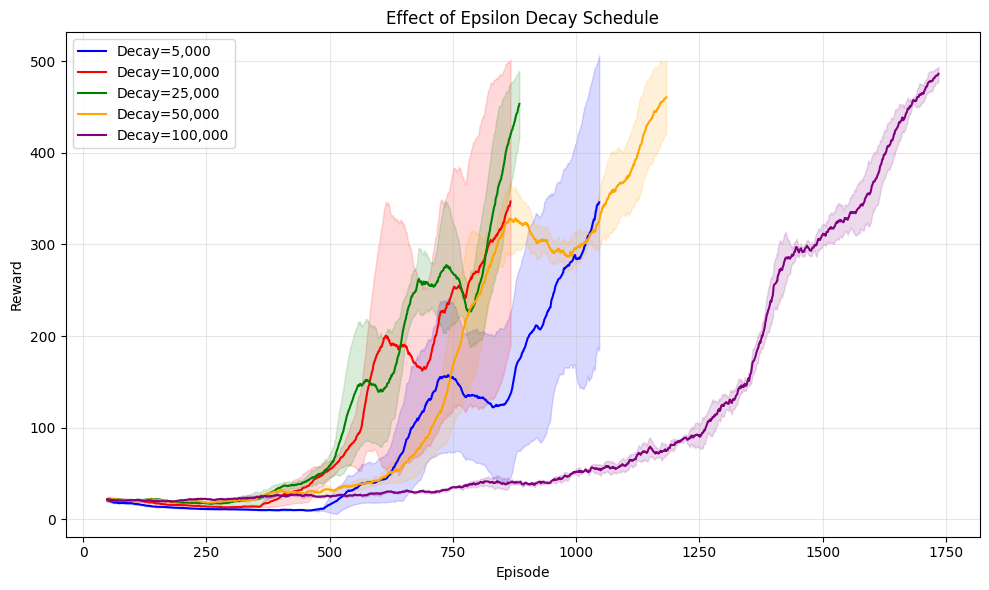

Decay=5,000: 476.3 ± 0.5
Decay=10,000: 476.0 ± 0.2
Decay=25,000: 475.7 ± 0.2
Decay=50,000: 475.1 ± 0.0
Decay=100,000: 476.1 ± 0.5


In [26]:
seeds = [42, 123, 456]
epsilon_decays = [5000, 10000, 25000, 50000, 100000]

eps_results = {}
for decay in epsilon_decays:
    eps_results[f'Decay={decay:,}'] = [
        train_dqn(env_name="CartPole-v1", num_episodes=2000, solve_threshold=475, epsilon_decay=decay, seed=s)
        for s in seeds
    ]

plot_comparison(eps_results, title="Effect of Epsilon Decay Schedule")

for name, results_list in eps_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

---

**Lab designed by Amath Sow:** amath.sow@liu.se

**TDDE78 — Deep Reinforcement Learning, Linköping University, Spring 2026**